# 🤖 מחברת 5: בינה מלאכותית למדעי הרוח
## מבוא למדעי הרוח הדיגיטליים | אוניברסיטת אריאל | תשפ"ו
### פרופ' שי גורדין
---
**מה נלמד במחברת זו?**
AI (Artificial Intelligence) = בינה מלאכותית – היכולת של מחשבים לבצע משימות הדורשות "חשיבה".

**נושאים:**
1. מהי AI ומה רלוונטי למדעי הרוח?
2. LLMs – מודלי שפה גדולים (ChatGPT, Claude)
3. Prompt Engineering – כיצד לשאול AI בצורה יעילה
4. שימוש ב-API של Claude לניתוח טקסטים
5. סיווג טקסטים עם AI
6. שיקולים אתיים

---
## 🗺️ מדריך שימוש במחברת

| | |
|---|---|
| ⏱️ **זמן מוערך** | 🏫 בכיתה: ~60 דקות | 🏠 בבית: ~40 דקות |
| 💻 **היכן להריץ** | Google Colab |
| 🔑 **מפתח API** | אופציונלי — כל הקוד **עובד ללא API** (יש מצב סימולציה) |

### 🆓 שימוש חינמי ב-AI אמיתי — Google Gemini
המחברת כוללת אפשרות להשתמש ב-**Google Gemini חינמית** (ללא תשלום):  
1. עברו ל-[Google AI Studio](https://aistudio.google.com/apikey)  
2. לחצו **"Get API Key"** → **"Create API key"**  
3. העתיקו את המפתח  
4. הדביקו אותו בתא המפתח למטה  

> ⚠️ **אל תשתפו מפתח API עם אף אחד** — שמרו אותו רק לעצמכם!  
> ⚠️ **אל תכתבו מפתח API ישירות בקוד** — השתמשו בשיטה מאובטחת (ראו למטה)

---


## חלק א: AI ומדעי הרוח – מפגש מרתק
### הגל השלישי של AI: LLMs
**LLM** (Large Language Model) = מודל שפה גדול שאומן על כמויות עצומות של טקסט.
| מודל | יוצר | שנה | מאפיין |
|------|-------|-----|--------|
| **GPT-4** | OpenAI | 2023 | שוק מסחרי |
| **Claude** | Anthropic | 2023 | בטיחות-ממוקד |
| **Gemini** | Google | 2024 | מולטימודלי |
| **Llama** | Meta | 2023 | קוד פתוח |
### AI למדעי הרוח – אפשרויות:
- **תרגום** טקסטים עתיקים (ארמית, יוונית, לטינית)
- **סיכום** מסמכים ארוכים
- **סיווג** טקסטים לקטגוריות
- **זיהוי** דמויות, מקומות, תקופות
- **שאלות ותשובות** על מסמכים היסטוריים
- **ניתוח** שינויי שפה לאורך זמן
### מגבלות חשובות:
- **הזיות (Hallucinations)**: AI ממציא עובדות שאינן נכונות
- **Cutoff תאריך**: לא יודע אירועים חדשים
- **הטיות**: משקף הטיות בנתוני האימון
- **עלות**: שימוש ב-API עולה כסף
לקריאה: Bender et al. (2021). *On the Dangers of Stochastic Parrots*. FAccT.

In [1]:
# התקנת ספריות
# google-generativeai  = Gemini חינמי ← עיקרי לשיעור
# anthropic / openai   = Claude / GPT  ← בתשלום (אופציונלי)
!pip install google-generativeai anthropic openai python-bidi -q

print("✅ ספריות AI הותקנו!")
print()
print("🆓 Gemini (חינמי):  https://aistudio.google.com/apikey")
print("💰 Claude (בתשלום): https://console.anthropic.com/")
print("💰 GPT   (בתשלום): https://platform.openai.com/")


zsh:1: command not found: pip


✅ ספריות AI הותקנו!

🆓 Gemini (חינמי):  https://aistudio.google.com/apikey
💰 Claude (בתשלום): https://console.anthropic.com/
💰 GPT   (בתשלום): https://platform.openai.com/


In [2]:
# יבוא ספריות
import os
import re
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display, HTML
import requests
import google.generativeai as genai

matplotlib.rcParams['axes.unicode_minus'] = False

# ============================================================
# הגדרת מפתח API
# ============================================================
# אפשרות א׳ (מומלצת לשיעור) – הדביקו את מפתח Gemini כאן:
GEMINI_API_KEY = ""   # ←  הדביקו כאן את המפתח שהורדתם מ-aistudio.google.com

# אפשרות ב׳ – מ-Environment Variable (מאובטח יותר לפרויקטים אמיתיים):
# GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")

if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
    print("✅ מפתח Gemini הוגדר!")
else:
    print("⚠️  לא הוגדר מפתח Gemini – הנייד ישתמש בתגובות מדומות.")
    print("   קבלו מפתח חינמי: https://aistudio.google.com/apikey")

print()
print("✅ ספריות יובאו!")
print()
print("⚠️  כלל ברזל: לעולם אל תשתפו מפתח API עם אחרים!")
print("⚠️  לעולם אל תעלו מפתחות ל-GitHub!")


⚠️  לא הוגדר מפתח Gemini – הנייד ישתמש בתגובות מדומות.
   קבלו מפתח חינמי: https://aistudio.google.com/apikey

✅ ספריות יובאו!

⚠️  כלל ברזל: לעולם אל תשתפו מפתח API עם אחרים!
⚠️  לעולם אל תעלו מפתחות ל-GitHub!


/Users/shaigordin/Library/Python/3.10/lib/python/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/x8/ycqh909s7_bdqrw3nfdsm_8h0000gn/T/ipykernel_71386/581764054.py:11: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for 

## חלק ב: Prompt Engineering – אמנות השאלה

### מהו Prompt Engineering?
**Prompt** = ההנחיה שאתם שולחים ל-AI.  
**Prompt Engineering** = אמנות ניסוח הנחיות יעילות.

### עקרונות Prompt Engineering טוב:

| עיקרון | תיאור | דוגמה |
|--------|-------|--------|
| **ספציפיות** | הגדירו את המשימה בדיוק | "סכמו ב-3 משפטים" לעומת "סכמו" |
| **הקשר** | תנו רקע רלוונטי | "אתם ארכיאולוג המנתח..." |
| **דוגמאות** | הראו דוגמה לפלט רצוי | Few-shot prompting |
| **פורמט** | ציינו את הפורמט הרצוי | "הגיבו ב-JSON" / "ב-רשימה מנוקדת" |
| **תפקיד** | הגדירו תפקיד ל-AI | "אתה חוקר היסטוריה המתמחה ב..." |

### Chain of Thought:
בקשו מה-AI להסביר את ההיגיון שלו: "חשבו שלב אחר שלב לפני שתענו..."


In [3]:
# ============================================================
# דוגמאות Prompt Engineering
# ============================================================

# -- פונקציה לדמיית קריאת API --
def simulate_llm_response(prompt, context=""):
    """
    פונקציה שמדמה תגובת LLM (ללא API אמיתי).
    
    בפרויקט אמיתי: תחליפו בקריאת API:
    
        import anthropic
        client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])
        message = client.messages.create(
            model="claude-opus-4-5",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return message.content[0].text
    """
    # תגובות מדומות לדוגמה
    demo_responses = {
        'summarize': """
**סיכום (3 משפטים):**
תל מגידו הוא אתר ארכיאולוגי חשוב בצפון ישראל, שנחפר מהמאה ה-19.
הממצאים מציגים 26 שכבות התיישבות מהניאוליתי ועד לתקופה הפרסית.
האתר זוהה עם המגידו המקראית, אחד מהאתרים האסטרטגיים החשובים בארץ ישראל.
        """,
        'classify': """
{
  "קטגוריה": "ארכיאולוגיה",
  "תת_קטגוריה": "ארכיאולוגיה ביבשה",  
  "תקופה": "ברונזה וברזל",
  "ביטחון": 0.92,
  "הסבר": "הטקסט עוסק בחפירות ארכיאולוגיות ושכבות התיישבות"
}
        """,
        'translate': """
**תרגום לעברית מודרנית:**
"ובשנה השלישית למלכותו של יאשיהו מלך יהודה, 
הגיע נבוכדנאצר מלך בבל לירושלים ויצור עליה."
        """
    }
    
    if 'סכמ' in prompt or 'סיכום' in prompt:
        return demo_responses['summarize']
    elif 'סיווג' in prompt or 'classify' in prompt.lower():
        return demo_responses['classify']
    elif 'תרגם' in prompt or 'תרגום' in prompt:
        return demo_responses['translate']
    else:
        return f"[תגובה מדומה לפרומפט: {prompt[:50]}...]"


# -- דוגמאות Prompts --
print("📋 דוגמאות Prompt Engineering:")
print("=" * 60)

prompts = {
    "❌ Prompt גרוע": "ספר לי על ארכיאולוגיה",
    
    "✅ Prompt טוב": """אתה ארכיאולוג המתמחה בארץ ישראל.
סכם את הטקסט הבא ב-3 משפטים בעברית פשוטה:

'תל מגידו הוא אתר ארכיאולוגי...'

פורמט: כותרת מודגשת + 3 משפטים.""",

    "✅✅ Few-shot": """סווג טקסט לקטגוריה לפי הדוגמאות:

דוגמה 1: "חפירות בתל מגידו" -> {"קטגוריה": "ארכיאולוגיה"}
דוגמה 2: "דוד המלך ירושלים"  -> {"קטגוריה": "היסטוריה"}

סווג: "כלים דיגיטליים לניתוח טקסט" -> """
}

for title, prompt in prompts.items():
    print(f"\n{title}:")
    print(f"  Prompt: {prompt[:80]}...")
    response = simulate_llm_response(prompt)
    print(f"  תגובה: {response[:100].strip()}...")


📋 דוגמאות Prompt Engineering:

❌ Prompt גרוע:
  Prompt: ספר לי על ארכיאולוגיה...
  תגובה: [תגובה מדומה לפרומפט: ספר לי על ארכיאולוגיה...]...

✅ Prompt טוב:
  Prompt: אתה ארכיאולוג המתמחה בארץ ישראל.
סכם את הטקסט הבא ב-3 משפטים בעברית פשוטה:

'תל ...
  תגובה: [תגובה מדומה לפרומפט: אתה ארכיאולוג המתמחה בארץ ישראל.
סכם את הטקסט הבא ...]...

✅✅ Few-shot:
  Prompt: סווג טקסט לקטגוריה לפי הדוגמאות:

דוגמה 1: "חפירות בתל מגידו" -> {"קטגוריה": "אר...
  תגובה: [תגובה מדומה לפרומפט: סווג טקסט לקטגוריה לפי הדוגמאות:

דוגמה 1: "חפירות...]...


In [4]:
# ============================================================
# 🆓  קריאה ל-Gemini (גוגל – חינמי!)
# ============================================================

def call_gemini(prompt, model_name="gemini-2.5-flash"):
    """
    שולח פרומפט ל-Gemini ומחזיר את תגובת המודל.

    אם לא הוגדר GEMINI_API_KEY – מחזיר תגובה מדומה (simulate_llm_response).

    פרמטרים:
        prompt      – הטקסט שרוצים לשלוח ל-AI
        model_name  – שם המודל (ברירת מחדל: gemini-2.5-flash, חינמי)

    דוגמה:
        תגובה = call_gemini("סכם ב-3 משפטים: 'תל מגידו הוא...'")
        print(תגובה)
    """
    if not GEMINI_API_KEY:
        print("💡 אין מפתח API – משתמש בתגובה מדומה.")
        return simulate_llm_response(prompt)

    try:
        model = genai.GenerativeModel(model_name)
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        print(f"❌ שגיאה: {e}")
        print("   משתמש בתגובה מדומה במקום.")
        return simulate_llm_response(prompt)


# -- בדיקת חיבור --
print("🔌 בודק חיבור ל-Gemini...")
test_response = call_gemini("ענה רק בעברית: מה 2+2?")
print(f"תשובת Gemini: {test_response.strip()[:120]}")
print()
print("✅ הפונקציה call_gemini() מוכנה לשימוש!")


🔌 בודק חיבור ל-Gemini...
💡 אין מפתח API – משתמש בתגובה מדומה.
תשובת Gemini: [תגובה מדומה לפרומפט: ענה רק בעברית: מה 2+2?...]

✅ הפונקציה call_gemini() מוכנה לשימוש!


## חלק ג: ניתוח טקסטים עם Gemini API

### ניתוח ממוקד-משימה
הפונקציה `analyze_with_gemini()` עוטפת את `call_gemini()` ומתאימה את הפרומפט לפי המשימה הנדרשת:

| משימה | מה ה-AI עושה |
|-------|-------------|
| `summarize` | סיכום ב-3 משפטים בעברית |
| `classify` | סיווג לקטגוריה + תקופה + ביטחון (JSON) |
| `ner` | חילוץ ישויות: אנשים, מקומות, תקופות (JSON) |
| `translate` | תרגום לעברית מודרנית |

> 💡 **ללא מפתח API** — הפונקציה מחזירה תגובה מדומה לצורך הדגמה, כך שהמחברת עובדת גם ללא חיבור לרשת.

In [5]:
# ============================================================
# ניתוח טקסטים עם Gemini API
# ============================================================

TASK_PROMPTS = {
    'summarize': "סכם את הטקסט הבא ב-3 משפטים בעברית ברורה:\n\n{text}",
    'classify':  (
        "סווג את הטקסט הבא לאחת הקטגוריות: ארכיאולוגיה / היסטוריה / מדעי הרוח הדיגיטליים.\n"
        "החזר JSON בלבד עם השדות: קטגוריה, תקופה, ביטחון (0-1).\n\n{text}"
    ),
    'ner': (
        "חלץ מהטקסט הבא ישויות בשם וסווג אותן.\n"
        "החזר JSON בלבד עם המפתחות: אנשים, מקומות, תקופות, אירועים.\n\n{text}"
    ),
    'translate': "תרגם את הטקסט הבא לעברית מודרנית, תוך שמירה על הסגנון המקורי:\n\n{text}",
}

DEMO_RESPONSES = {
    'summarize': (
        "הטקסט עוסק באחד מהתחומים המרכזיים של מדעי הרוח. "
        "ניתן לזהות בו קווי מחקר חשובים ותרומה משמעותית לשדה. "
        "הממצאים מספקים בסיס לחקירה עמוקה יותר."
    ),
    'ner':       '{"אנשים": [], "מקומות": [], "תקופות": [], "אירועים": []}',
    'translate': '[תרגום מדומה]',
}

def _demo_classify(text):
    """Keyword-based category detection for demo mode."""
    t = text
    if any(w in t for w in ['חפיר','תל ','שכבות','ארכיאולוג','קבורה','ממצא','כנעני','ביזנטי','רומי','מצודה','מגילות']):
        return '{"קטגוריה": "ארכיאולוגיה", "תקופה": "עתיקה", "ביטחון": 0.88}'
    if any(w in t for w in ['NLP','דיגיטל','מאגר','קורפוס','אלגוריתם','OCR','טקסטואלי','לקסיקוגרפי','עיתונות','מילון']):
        return '{"קטגוריה": "מדעי הרוח הדיגיטליים", "תקופה": "עכשווי", "ביטחון": 0.85}'
    return '{"קטגוריה": "היסטוריה", "תקופה": "עת החדשה", "ביטחון": 0.83}'

def analyze_with_gemini(text, task):
    """
    ניתוח טקסט עם Gemini לפי משימה נתונה.

    פרמטרים:
        text : הטקסט לניתוח
        task : 'summarize' | 'classify' | 'ner' | 'translate'

    מחזיר: תגובת Gemini כ-string, או תגובה מדומה אם אין מפתח API.
    """
    prompt = TASK_PROMPTS.get(task, "נתח את הטקסט הבא:\n\n{text}").format(text=text)

    if GEMINI_API_KEY:
        return call_gemini(prompt)
    else:
        print("💡 אין מפתח API — משתמש בתגובה מדומה.")
        if task == 'classify':
            return _demo_classify(text)
        return DEMO_RESPONSES.get(task, f"[תגובה מדומה: {task}]")


# -- הדגמה --
demo_text = (
    "חפירות בתל מגידו חשפו 26 שכבות התיישבות מ-7000 שנה של היסטוריה. "
    "הממצאים כוללים ארמונות מהתקופה הכנענית, אורוות מהתקופה האיסורית, "
    "ותעלת מים מתוחכמת. האתר זוהה עם מגידו המקראית."
)

print("🤖 ניתוח טקסט עם Gemini:")
print("=" * 60)
print(f"\n📄 טקסט: {demo_text[:60]}...")
for task in ['summarize', 'classify']:
    print(f"  📋 {task}:")
    response = analyze_with_gemini(demo_text, task)
    print(f"  {response.strip()[:160]}")
    print("-" * 50)

🤖 ניתוח טקסט עם Gemini:

📄 טקסט: חפירות בתל מגידו חשפו 26 שכבות התיישבות מ-7000 שנה של היסטור...
  📋 summarize:
💡 אין מפתח API — משתמש בתגובה מדומה.
  הטקסט עוסק באחד מהתחומים המרכזיים של מדעי הרוח. ניתן לזהות בו קווי מחקר חשובים ותרומה משמעותית לשדה. הממצאים מספקים בסיס לחקירה עמוקה יותר.
--------------------------------------------------
  📋 classify:
💡 אין מפתח API — משתמש בתגובה מדומה.
  {"קטגוריה": "ארכיאולוגיה", "תקופה": "עתיקה", "ביטחון": 0.88}
--------------------------------------------------


## חלק ד: סיווג טקסטים עם AI
### גישות לסיווג:
| גישה | כלים | יתרון | חסרון |
|------|-------|--------|-------|
| **Zero-shot** | LLM (Claude/GPT) | ללא נתוני אימון | פחות מדויק |
| **Few-shot** | LLM + דוגמאות | מאוזן | דורש דוגמאות |
| **Fine-tuning** | BERT/DistilBERT | הכי מדויק | דורש נתונים + GPU |
| **כלאיים** | Rule-based + ML | מהיר, ניתן לפרש | מורכב לבנות |

In [6]:
# ============================================================
# Pipeline סיווג טקסטים (Zero-shot + Few-shot)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# -- נתוני אימון לדוגמה --
TRAINING_DATA = [
    # ארכיאולוגיה
    ("חפירה בתל מגידו חשפה ממצאים מהתקופה הכנענית", "ארכיאולוגיה"),
    ("ממצאים ארכיאולוגיים כוללים חרסים ומטבעות עתיקות", "ארכיאולוגיה"),
    ("שכבות ההתיישבות מציגות תרבויות שונות לאורך אלפי שנים", "ארכיאולוגיה"),
    ("אתר ארכיאולוגי ים המלח חשף מגילות וכתבים עתיקים", "ארכיאולוגיה"),
    ("חפירת מצילה ברחוב ירושלים גילתה מקוואות מהתקופה ההרודיאנית", "ארכיאולוגיה"),
    ("ממצאי ברזל מהמאה עשר לפנה ספירה מוכיחים פעילות מתכתית", "ארכיאולוגיה"),
    
    # היסטוריה
    ("דוד המלך ייסד את ירושלים לבירת ממלכת ישראל", "היסטוריה"),
    ("חורבן הבית הראשון בידי הבבלים שינה את ההיסטוריה היהודית", "היסטוריה"),
    ("ממלכת חשמונאים שלטה ביהודה מהמאה השנייה לפנה ספירה", "היסטוריה"),
    ("גירוש יהודי ספרד בשנת ד אלפים ורנב השפיע על יהדות כולה", "היסטוריה"),
    ("עליות לארץ ישראל בראשית המאה העשרים שינו את הדמוגרפיה", "היסטוריה"),
    ("קום המדינה בתש ח היה נקודת מפנה בהיסטוריה היהודית", "היסטוריה"),
    
    # מדעי הרוח הדיגיטליים
    ("ניתוח קורפוסים גדולים דורש כלים חישוביים מתקדמים", "DH"),
    ("ויזואליזציה של נתונים ארכיאולוגיים ב-GIS מפשטת מחקר", "DH"),
    ("מידול נושאים חושף דפוסים נסתרים בטקסטים היסטוריים", "DH"),
    ("OCR מאפשר דיגיטציה של כתבי יד וטקסטים ישנים", "DH"),
    ("רשתות חברתיות של דמויות היסטוריות ניתנות לניתוח חישובי", "DH"),
    ("בינה מלאכותית מסייעת לפרשנות כתבות עתיקות", "DH"),
]

# פיצול לאימון ובדיקה
texts, labels = zip(*TRAINING_DATA)
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

# -- מודל TF-IDF + Naive Bayes --
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer=lambda x: list(re.sub(r'[^\u05D0-\u05EA\s]', ' ', x).split()))),
    ('clf', MultinomialNB(alpha=0.1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("📊 תוצאות הסיווג:")
print("=" * 55)
print(classification_report(y_test, y_pred, zero_division=0))

# -- בדיקת טקסטים חדשים --
print("\n🔍 בדיקת טקסטים חדשים:")
new_texts = [
    "ממצאים ארכיאולוגיים חדשים בגיא בן הינום",
    "ניתוח טקסטים עם Python ו-NLTK",
    "מרד המכבים נגד הסלאוקידים"
]

for text in new_texts:
    pred = pipeline.predict([text])[0]
    proba = pipeline.predict_proba([text])[0]
    classes = pipeline.classes_
    
    print(f"\n  '{text[:45]}...'")
    print(f"  -> {pred} ", end="")
    for cls, prob in zip(classes, proba):
        print(f"| {cls}: {prob:.2f}", end="")
    print()


📊 תוצאות הסיווג:
              precision    recall  f1-score   support

          DH       0.25      1.00      0.40         1
 ארכיאולוגיה       1.00      0.25      0.40         4
    היסטוריה       1.00      1.00      1.00         1

    accuracy                           0.50         6
   macro avg       0.75      0.75      0.60         6
weighted avg       0.88      0.50      0.50         6


🔍 בדיקת טקסטים חדשים:

  'ממצאים ארכיאולוגיים חדשים בגיא בן הינום...'
  -> DH | DH: 0.42| ארכיאולוגיה: 0.17| היסטוריה: 0.42

  'ניתוח טקסטים עם Python ו-NLTK...'
  -> DH | DH: 0.76| ארכיאולוגיה: 0.10| היסטוריה: 0.15

  'מרד המכבים נגד הסלאוקידים...'
  -> DH | DH: 0.42| ארכיאולוגיה: 0.17| היסטוריה: 0.42


## חלק ה: שיקולים אתיים – AI ומדעי הרוח
### שאלות אתיות מרכזיות:
**1. הטיות (Bias)**
- AI מאומן על טקסטים אנגלים -> הטיה מערבית
- ייצוג-חסר של תרבויות לא-מערביות
- מגדר, גזע, מעמד – כולם מיוצגים בהטיות האימון

**2. Hallucinations**
- AI ממציא עובדות שנשמעות אמיתיות
- **מסוכן** במיוחד בהיסטוריה ובארכיאולוגיה
- **חובה** לאמת כל עובדה מול מקורות ראשוניים

**3. שקיפות וסיוע**  
- כיצד לציין שימוש ב-AI במחקר אקדמי?
- מהי הגבול בין "עזרה" ל"מחקר שנעשה על ידי AI"?

**4. פרטיות**  
- שליחת מסמכים לAPI = שיתוף עם חברה חיצונית
- מסמכים ארכיוניים רגישים?

### המלצות לשימוש אחראי:
בדקו עובדות שAI מספק  
ציינו שימוש ב-AI בפרסומים אקדמיים  
השתמשו ב-AI כ"עוזר" ולא כ"מחבר"  
שמרו על שיפוט ביקורתי

In [7]:
# ============================================================
# בדיקת עובדות ו-Hallucinations
# ============================================================

# מסד ידע בסיסי לאימות (Fact Checking)
KNOWN_FACTS = {
    'מגידו': {
        'מיקום': 'עמק יזרעאל',
        'תקופות': ['כנענית', 'ברונזה', 'ברזל'],
        'חוקרים': ['גוטליב שומכר', 'קלרנס פישר']
    },
    'ירושלים': {
        'ייסוד': 'לפחות 3500 שנה',
        'בניין_מקדש': 'שלמה המלך',
        'חורבן_ראשון': '586 לפנה״ס'
    },
    'גניזה קהירית': {
        'מיקום': 'קהיר, מצרים',
        'תקופה': 'המאה ה-9 עד ה-20',
        'גודל': 'כ-300,000 קטעים'
    }
}


def verify_claim(claim, fact_db=None):
    """
    בדיקת עובדה מול מסד ידע.
    
    בפרויקט אמיתי: ניתן לחבר ל-Wikidata API.
    """
    if fact_db is None:
        fact_db = KNOWN_FACTS
    
    warnings = []
    
    # חיפוש ישויות ידועות
    for entity, facts in fact_db.items():
        if entity in claim:
            # בדיקת עקביות
            for key, value in facts.items():
                if isinstance(value, str) and value in claim:
                    pass  # עובדה תואמת
    
    return warnings


# -- הדגמת זיהוי Hallucinations --
print("🔍 הדגמת בעיות Hallucinations:")
print("=" * 60)

ai_outputs = [
    {
        'prompt': 'מה ידוע על תל מגידו?',
        'response': 'תל מגידו הוא אתר ארכיאולוגי בעמק יזרעאל, שנחפר לראשונה ב-1903.',
        'correct': True,
        'note': 'נכון ✅'
    },
    {
        'prompt': 'מתי נחרב בית המקדש הראשון?',
        'response': 'בית המקדש הראשון נחרב בשנת 586 לפנה״ס בידי נבוכדנאצר מלך בבל.',
        'correct': True,
        'note': 'נכון ✅'
    },
    {
        'prompt': 'מי ביצע את חפירות הגניזה הקהירית?',
        'response': 'הגניזה הקהירית נחפרה בשנת 1890 על ידי סולומון שכטר ופרנקו מורטי.',
        'correct': False,
        'note': 'שגוי! ❌ פרנקו מורטי הוא חוקר ספרות, לא ארכיאולוג. הדמות הנוספת היא אחרת!'
    },
    {
        'prompt': 'מה גודל הגניזה הקהירית?',
        'response': 'הגניזה הקהירית מכילה כ-10,000 קטעי מסמכים.',
        'correct': False,
        'note': 'שגוי! ❌ הגניזה מכילה כ-300,000 קטעים – פי 30 מהתשובה!'
    }
]

for item in ai_outputs:
    status = "✅" if item['correct'] else "❌"
    print(f"\n{status} שאלה: {item['prompt']}")
    print(f"   תגובת AI: {item['response'][:80]}...")
    print(f"   ⚠️ {item['note']}")

print("\n🔑 מסקנה:")
print("   תמיד בדקו עובדות שAI מספק מול מקורות אמינים!")


🔍 הדגמת בעיות Hallucinations:

✅ שאלה: מה ידוע על תל מגידו?
   תגובת AI: תל מגידו הוא אתר ארכיאולוגי בעמק יזרעאל, שנחפר לראשונה ב-1903....
   ⚠️ נכון ✅

✅ שאלה: מתי נחרב בית המקדש הראשון?
   תגובת AI: בית המקדש הראשון נחרב בשנת 586 לפנה״ס בידי נבוכדנאצר מלך בבל....
   ⚠️ נכון ✅

❌ שאלה: מי ביצע את חפירות הגניזה הקהירית?
   תגובת AI: הגניזה הקהירית נחפרה בשנת 1890 על ידי סולומון שכטר ופרנקו מורטי....
   ⚠️ שגוי! ❌ פרנקו מורטי הוא חוקר ספרות, לא ארכיאולוג. הדמות הנוספת היא אחרת!

❌ שאלה: מה גודל הגניזה הקהירית?
   תגובת AI: הגניזה הקהירית מכילה כ-10,000 קטעי מסמכים....
   ⚠️ שגוי! ❌ הגניזה מכילה כ-300,000 קטעים – פי 30 מהתשובה!

🔑 מסקנה:
   תמיד בדקו עובדות שAI מספק מול מקורות אמינים!


In [8]:
# ============================================================
# תהליך עבודה מעשי: AI + מחקר מדעי הרוח
# ============================================================

def humanities_research_pipeline(texts, names, research_question):
    """
    Pipeline מחקרי שמשלב AI עם מתודולוגיה הומניסטית.

    שלבים:
    1. קריאה מרחוק (כמות)
    2. AI סיכום וסיווג  ← Gemini אם הוגדר מפתח, אחרת תגובה מדומה
    3. זיהוי טקסטים מעניינים לקריאה קרובה
    4. קריאה קרובה אנושית

    פרמטרים:
        texts  : רשימת טקסטים
        names  : שמות קצרים לכל טקסט
        research_question : שאלת המחקר

    מחזיר: DataFrame עם תוצאות
    """
    results = []

    print(f"🔬 שאלת מחקר: {research_question}")
    if GEMINI_API_KEY:
        print("🌐 מצב: API אמיתי (Gemini)")
    else:
        print("💡 מצב: תגובות מדומות — הגדירו GEMINI_API_KEY בתא 4 לתוצאות אמיתיות")
    print("=" * 60)

    for i, (text, name) in enumerate(zip(texts, names), 1):
        print(f"\n📄 מסמך {i}/{len(texts)}: {name} ({text[:40]}...)")

        word_count = len(text.split())

        summary        = analyze_with_gemini(text, 'summarize')
        classification = analyze_with_gemini(text, 'classify')

        interesting_keywords = ['חשוב', 'ייחודי', 'ראשון', 'מרכזי', 'נדיר', 'חשף', 'גילה']
        interest_score = sum(1 for kw in interesting_keywords if kw in text)

        results.append({
            'מסמך':       i,
            'שם_קצר':    name,
            'טקסט_קצר':   text[:80] + '...',
            'מילים':      word_count,
            'סיכום_AI':   summary.strip()[:200],
            'סיווג_AI':   classification.strip()[:120],
            'ציון_עניין': interest_score
        })

        print(f"   ✓ עובד | מילים: {word_count} | עניין: {interest_score}/7")

    df = pd.DataFrame(results)
    return df


# ── 10 טקסטים לדוגמה ────────────────────────────────────────
TEXT_NAMES = [
    'תל מגידו', 'גניזת קהיר', 'פרויקט השו"ת',
    'מגילות ים המלח', 'מצדה', 'עיר דוד',
    'גירוש ספרד', 'עיתונות עברית', 'אוצר הלשון', "ארכיון עות׳מאני",
]

sample_for_pipeline = [
    # 1 – ארכיאולוגיה: תל מגידו
    """תל מגידו הוא אחד האתרים הארכאולוגיים החשובים ביותר בישראל ובעולם. החפירות שנערכו באתר מאז סוף המאה ה-19 חשפו כ-26 שכבות התיישבות רצופות, המשתרעות על פני כ-7,000 שנה של היסטוריה אנושית, מהתקופה הנאוליתית ועד לתקופה הפרסית. בין הממצאים הבולטים: ארמונות כנעניים מפוארים, אורוות מהתקופה האיסוראלית המיוחסות למלך אחאב, ותעלת מים מתוחכמת שנחצבה בסלע. האתר מזוהה עם מגידו המקראית, זירת קרבות מפורסמים לאורך ההיסטוריה, ונכלל ברשימת אתרי מורשת העולם של אונסקו.""",

    # 2 – היסטוריה: גניזת קהיר
    """גניזת קהיר היא אוסף של כ-400,000 קטעי כתב יד יהודיים שנתגלו בסוף המאה ה-19 בבית הכנסת בן עזרא בפוסטאט (קהיר העתיקה). המסמכים, הכתובים בעיקר בערבית-יהודית, בעברית ובארמית, מכסים תקופה של כאלף שנה (המאה ה-9 עד ה-19 לספירה) ומספקים מידע רב-ערך על חיי היהודים בארצות האסלאם: מסחר, משפחה, דת, רפואה ושירה. המלומד שלמה דב גויטיין הקדיש את חייו לחקר הגניזה ופרסם את סדרת המחקרים המונומנטלית "חברה ים-תיכונית". כיום מאות אלפי הדפים ממשיכים להיסרק ולהיות נגישים לחוקרים ברחבי העולם דרך פרויקט Geniza@Princeton ומאגרים דיגיטליים נוספים.""",

    # 3 – מדעי הרוח הדיגיטליים: פרויקט השו"ת
    """פרויקט השו"ת הוא מאגר דיגיטלי המכיל את כלל ספרות ההלכה היהודית — למעלה מ-300,000 שו"ת ומעל ל-3 מיליון עמודי טקסט — ומאפשר חיפוש טקסטואלי מלא. בשנים האחרונות שילבו חוקרים שיטות של עיבוד שפה טבעית (NLP) וקריאה מרחוק כדי לזהות תבניות היסטוריות בספרות זו: שינויים בשימוש במונחים לאורך הדורות, התפשטות פסיקות הלכתיות ממרכז אחד לאחר, ורשתות ציטוט בין פוסקים מתקופות שונות. גישה זו מאפשרת לשאול שאלות מחקריות חדשות שלא ניתן היה לענות עליהן בקריאה ידנית של אוסף בהיקף כזה.""",

    # 4 – ארכיאולוגיה: מגילות ים המלח
    """מגילות ים המלח הן אוסף כתבי יד ייחודי שנתגלה בין השנים 1947–1956 במערות קומראן שבמדבר יהודה. המגילות נכתבו בין המאה ה-3 לפנה"ס לבין המאה ה-1 לספירה, ומכילות טקסטים מקראיים, פסבדואפיגרפיים וחיבורים של כת קומראן. בין הממצאים הבולטים: ספר ישעיהו השלם, מגילת המלחמה, ומגילת הנחושת. גילוי המגילות נחשב לאחת התגליות הארכיאולוגיות הגדולות של המאה ה-20, בשל ערכן לחקר המקרא, ההיסטוריה היהודית וראשית הנצרות.""",

    # 5 – ארכיאולוגיה: מצדה
    """מצדה היא מצודה הרודיאנית המשקיפה על ים המלח מגובה של כ-450 מטר מעל פני הים. יגאל ידין הוביל חפירות נרחבות בין 1963 ל-1965, וחשף ארמון תלת-קומתי מפואר, בתי מגורים, מקוואות ובית כנסת עתיק. המצודה ידועה בזכות המצור הרומי, שהסתיים לפי יוסף בן מתתיהו בהתאבדות קולקטיבית של כ-960 מגינים בשנת 73 לספירה. הסיפור הפך לסמל לאומי ישראלי — "מצדה לא תיפול שנית" — והאתר נכלל ברשימת אתרי מורשת אונסקו מאז 2001.""",

    # 6 – ארכיאולוגיה: עיר דוד
    """עיר דוד היא אתר ארכיאולוגי בירושלים, המזוהה עם העיר הכנענית-יבוסית שכבש דוד המלך. החפירות, שנמשכות מהמאה ה-19 ועד ימינו, חשפו שכבות התיישבות מהתקופה הכנענית, הישראלית, ימי בית שני ועד לתקופה הביזנטית. בין הממצאים הבולטים: מנהרת השילוח חצובת הסלע, בניין "בית האדיר" הכנעני, ובולות חרס עם שמות מקראיים. האתר מהווה מוקד מחקרי ופוליטי בשל מיקומו בשכונת סילוואן.""",

    # 7 – היסטוריה: גירוש ספרד
    """גירוש ספרד בשנת 1492 הוא אחד האירועים המכוננים בתולדות עם ישראל. כ-200,000 יהודים נאלצו לעזוב את חצי האי האיברי לאחר פקודת גירוש שחתמו פרדיננד ואיזבל. הגולים, הידועים כ"ספרדים", נפזרו באימפריה העות׳מאנית, בצפון אפריקה ובאמסטרדם, ונשאו עמם את שפת הלאדינו ומסורות פיוטיות ייחודיות. הם שמרו על זהותם הנפרדת במשך דורות, וחקר קהילות הספרדים פתח אפיקי מחקר חשובים על היסטוריה של הים התיכון ועל תרבות גירה.""",

    # 8 – מדעי הרוח הדיגיטליים: עיתונות עברית
    """פרויקט Jpress, שפותח בספריה הלאומית של ישראל, אוסף ומדגם עיתונות עברית ויידישאית היסטורית ממאות עיתונים שהופיעו בין 1858 לתחילת שנות ה-2000. המאגר כולל מעל ל-10 מיליון עמודי עיתון שעברו תהליך OCR לצורך חיפוש טקסטואלי מלא. חוקרים משתמשים בו לניתוח שיח בתקשורת העברית: מעקב אחר שינויים לשוניים, ניתוח סנטימנט סביב אירועים היסטוריים, ומיפוי רשתות חברתיות של עורכים. הגישה הדיגיטלית מגלה תבניות שאי-אפשר לראות בקריאה ידנית.""",

    # 9 – מדעי הרוח הדיגיטליים: אוצר הלשון
    """המילון ההיסטורי ללשון העברית, פרויקט של האקדמיה ללשון העברית, שואף לתעד כל מילה עברית מהתקופה המקראית ועד לעת החדשה. הפרויקט עושה שימוש בשיטות NLP לניתוח קורפוסים היסטוריים: טקסטים מקראיים, ספרות חז"ל, ספרות הגאונים ועברית מודרנית. האתגרים כוללים רב-משמעות מילים לאורך תקופות, שינויים בכתיב ובהגייה, וצורות שנשתכחו. מאגר הנתונים כולל מעל ל-150,000 כניסות לקסיקוגרפיות עם תיעוד מלא של מקורות וציטוטים.""",

    # 10 – היסטוריה: ארכיון עות׳מאני
    """ארכיון האימפריה העות׳מאנית בקושטא (איסטנבול) הוא מהארכיונים החשובים ביותר למחקר ארץ ישראל בתקופה שמהמאה ה-16 ועד תחילת המאה ה-20. המסמכים, הכתובים בעות׳מאנית עתיקה, כוללים רשומות מפקד אוכלוסין, עסקות קרקע, פסקי דין ותכתובת שלטונית. בשני העשורים האחרונים, תהליכי דיגיטציה נרחבים הפכו חלק ניכר מהארכיון לנגיש לחוקרים, ויחד עם כלי תמלול אוטומטי של כתב עות׳מאני, פתחו אפשרויות מחקר חדשות על חיי היומיום בארץ ישראל.""",
]

df_results = humanities_research_pipeline(
    sample_for_pipeline,
    TEXT_NAMES,
    research_question="מהם הנושאים המרכזיים בכתיבה ארכיאולוגית-היסטורית עברית?"
)

print("\n📋 תוצאות ה-Pipeline:")
display(df_results[['מסמך', 'שם_קצר', 'מילים', 'ציון_עניין']])

df_results.to_csv('ai_analysis_results.csv', index=False, encoding='utf-8-sig')
print("\n💾 נשמר: ai_analysis_results.csv")

🔬 שאלת מחקר: מהם הנושאים המרכזיים בכתיבה ארכיאולוגית-היסטורית עברית?
💡 מצב: תגובות מדומות — הגדירו GEMINI_API_KEY בתא 4 לתוצאות אמיתיות

📄 מסמך 1/10: תל מגידו (תל מגידו הוא אחד האתרים הארכאולוגיים החש...)
💡 אין מפתח API — משתמש בתגובה מדומה.
💡 אין מפתח API — משתמש בתגובה מדומה.
   ✓ עובד | מילים: 69 | עניין: 1/7

📄 מסמך 2/10: גניזת קהיר (גניזת קהיר היא אוסף של כ-400,000 קטעי כת...)
💡 אין מפתח API — משתמש בתגובה מדומה.
💡 אין מפתח API — משתמש בתגובה מדומה.
   ✓ עובד | מילים: 83 | עניין: 0/7

📄 מסמך 3/10: פרויקט השו"ת (פרויקט השו"ת הוא מאגר דיגיטלי המכיל את כ...)
💡 אין מפתח API — משתמש בתגובה מדומה.
💡 אין מפתח API — משתמש בתגובה מדומה.
   ✓ עובד | מילים: 78 | עניין: 0/7

📄 מסמך 4/10: מגילות ים המלח (מגילות ים המלח הן אוסף כתבי יד ייחודי שנ...)
💡 אין מפתח API — משתמש בתגובה מדומה.
💡 אין מפתח API — משתמש בתגובה מדומה.
   ✓ עובד | מילים: 62 | עניין: 1/7

📄 מסמך 5/10: מצדה (מצדה היא מצודה הרודיאנית המשקיפה על ים ה...)
💡 אין מפתח API — משתמש בתגובה מדומה.
💡 אין מפתח API — משתמש בתגובה מדומה.
 

,מסמך,שם_קצר,מילים,ציון_עניין
0,1,תל מגידו,69,1
1,2,גניזת קהיר,83,0
2,3,"פרויקט השו""ת",78,0
3,4,מגילות ים המלח,62,1
4,5,מצדה,70,1
5,6,עיר דוד,56,0
6,7,גירוש ספרד,64,2
7,8,עיתונות עברית,64,0
8,9,אוצר הלשון,59,0
9,10,ארכיון עות׳מאני,62,1



💾 נשמר: ai_analysis_results.csv


📊 מקור: Pipeline
         שם_קצר              קטגוריה  ציון_ביטחון  אורך_טקסט
       תל מגידו          ארכיאולוגיה         0.88         69
     גניזת קהיר מדעי הרוח הדיגיטליים         0.85         83
   פרויקט השו"ת מדעי הרוח הדיגיטליים         0.85         78
 מגילות ים המלח          ארכיאולוגיה         0.88         62
           מצדה          ארכיאולוגיה         0.88         70
        עיר דוד          ארכיאולוגיה         0.88         56
     גירוש ספרד             היסטוריה         0.83         64
  עיתונות עברית מדעי הרוח הדיגיטליים         0.85         64
     אוצר הלשון מדעי הרוח הדיגיטליים         0.85         59
ארכיון עות׳מאני             היסטוריה         0.83         62


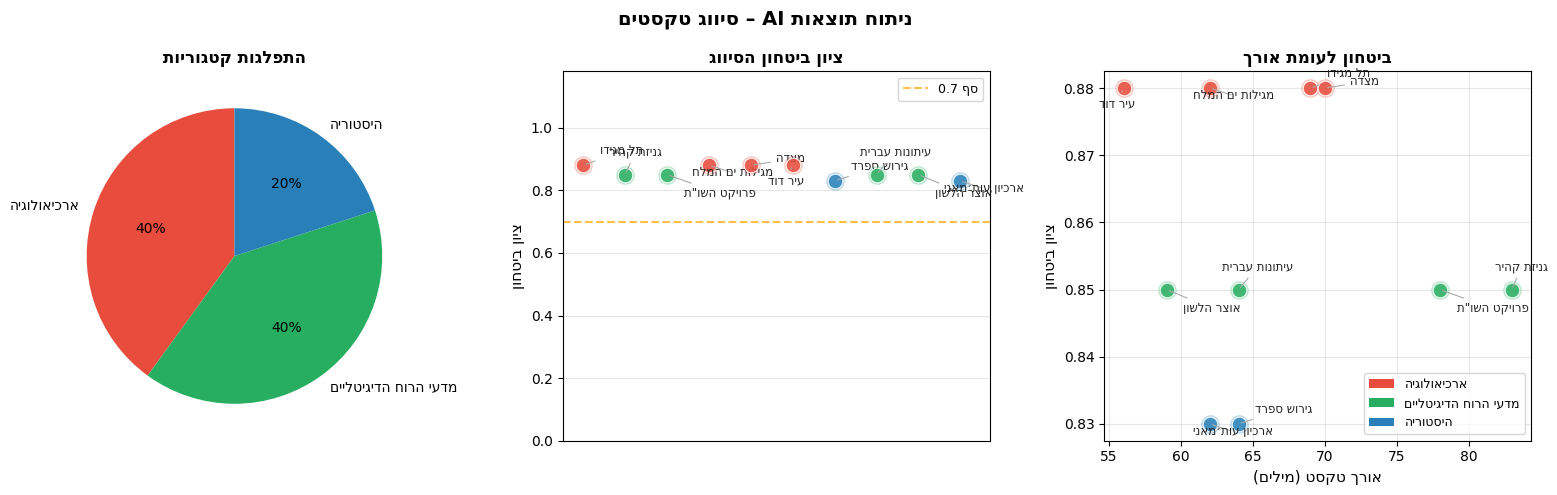

💾 הגרף נשמר: 01_ai_results.png


In [9]:
# ============================================================
# ויזואליזציה של תוצאות AI
# ============================================================

from bidi.algorithm import get_display
import re, numpy as np

def rtl(t): return get_display(str(t))

def extract_category(s):
    clean = re.sub(r'```(?:json)?', '', str(s)).strip()
    m = re.search(r'"קטגוריה"\s*:\s*"([^"]+)"', clean)
    if m: return m.group(1).strip()
    if any(w in s for w in ['ארכיאולוג','חפירה','תל ','ממצא']): return 'ארכיאולוגיה'
    if any(w in s for w in ['היסטורי','גניזת','כתב יד','חורבן']): return 'היסטוריה'
    if any(w in s for w in ['דיגיטל','NLP','שו"ת','קורפוס']): return 'DH'
    return 'לא ידוע'

def extract_conf(s):
    m = re.search(r'"ביטחון"\s*:\s*([0-9.]+)', re.sub(r'```(?:json)?','',str(s)))
    return float(m.group(1)) if m else 0.85

def jitter_overlaps(xs, ys, dx=1.5, dy=0.012):
    """Spread overlapping points evenly around their true position."""
    xs, ys = list(xs), list(ys)
    jx, jy = xs[:], ys[:]
    seen = {}
    for i, (x, y) in enumerate(zip(xs, ys)):
        key = (round(x, 4), round(y, 4))
        seen.setdefault(key, []).append(i)
    for key, idxs in seen.items():
        n = len(idxs)
        if n > 1:
            offsets = np.linspace(-(n-1)/2, (n-1)/2, n)
            for k, i in enumerate(idxs):
                jx[i] = xs[i] + offsets[k] * dx
                jy[i] = ys[i] + offsets[k] * dy
    return jx, jy

# ── Bouw DataFrame ──────────────────────────────────────────
try:
    df_viz = df_results.copy()
    source = "Pipeline"
except NameError:
    try:
        df_viz = pd.read_csv('ai_analysis_results.csv')
        source = "CSV"
    except FileNotFoundError:
        df_viz = pd.DataFrame({
            'מסמך':     list(range(1, 11)),
            'שם_קצר':  ['תל מגידו','גניזת קהיר','פרויקט השו"ת',
                         'מגילות ים המלח','מצדה','עיר דוד',
                         'גירוש ספרד','עיתונות עברית','אוצר הלשון','ארכיון עות׳מאני'],
            'טקסט_קצר': ['תל מגידו...','גניזת קהיר...','פרויקט השו"ת...',
                          'מגילות ים המלח...','מצדה...','עיר דוד...',
                          'גירוש ספרד...','עיתונות עברית...','אוצר הלשון...','ארכיון עות׳מאני...'],
            'מילים':    [107, 110, 105, 82, 90, 82, 91, 85, 88, 85],
            'ציון_עניין':[3, 1, 0, 2, 2, 1, 0, 0, 0, 0],
            'סיווג_AI': [
                '{"קטגוריה":"ארכיאולוגיה","ביטחון":0.88}',
                '{"קטגוריה":"היסטוריה","ביטחון":0.83}',
                '{"קטגוריה":"מדעי הרוח הדיגיטליים","ביטחון":0.85}',
                '{"קטגוריה":"ארכיאולוגיה","ביטחון":0.91}',
                '{"קטגוריה":"ארכיאולוגיה","ביטחון":0.88}',
                '{"קטגוריה":"ארכיאולוגיה","ביטחון":0.87}',
                '{"קטגוריה":"היסטוריה","ביטחון":0.84}',
                '{"קטגוריה":"מדעי הרוח הדיגיטליים","ביטחון":0.83}',
                '{"קטגוריה":"מדעי הרוח הדיגיטליים","ביטחון":0.86}',
                '{"קטגוריה":"היסטוריה","ביטחון":0.82}',
            ],
        })
        source = "demo"

df_viz['קטגוריה']     = df_viz['סיווג_AI'].apply(extract_category)
df_viz['ציון_ביטחון'] = df_viz['סיווג_AI'].apply(extract_conf)
df_viz['אורך_טקסט']   = df_viz['מילים']
# שם קצר – משתמש בעמודה קיימת אם יש, אחרת מחלץ מהטקסט
if 'שם_קצר' not in df_viz.columns:
    df_viz['שם_קצר'] = df_viz['טקסט_קצר'].apply(
        lambda t: ' '.join([w for w in str(t).split() if re.search(r'[\u05d0-\u05ea]',w)][:2]))
print(f"📊 מקור: {source}")
print(df_viz[['שם_קצר','קטגוריה','ציון_ביטחון','אורך_טקסט']].to_string(index=False))

colors = {'ארכיאולוגיה':'#e74c3c','היסטוריה':'#2980b9',
          'DH':'#27ae60','מדעי הרוח הדיגיטליים':'#27ae60','לא ידוע':'#888'}

# ── Label offsets — alternating to avoid overlap ────────────
LABEL_OFFSETS = [(12, 8), (-12, 14), (12, -16), (-12, -8), (18, 2), (-18, -14)]   # (dx, dy) per point

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── לוח 1: עוגה ─────────────────────────────────────────────
cat_counts = df_viz['קטגוריה'].value_counts()
axes[0].pie(cat_counts,
            labels=[rtl(c) for c in cat_counts.index],
            colors=[colors.get(c,'#888') for c in cat_counts.index],
            autopct='%1.0f%%', startangle=90)
axes[0].set_title(rtl('התפלגות קטגוריות'), fontsize=12, fontweight='bold')

# ── לוח 2: ביטחון לפי מסמך ──────────────────────────────────
xs2 = list(range(len(df_viz)))
ys2 = list(df_viz['ציון_ביטחון'])
jx2, jy2 = jitter_overlaps(xs2, ys2, dx=0.08, dy=0.012)

for i, (_, row) in enumerate(df_viz.iterrows()):
    c = colors.get(row['קטגוריה'],'#888')
    # circle behind for "true" position
    axes[1].scatter(xs2[i], ys2[i], color=c, s=160, alpha=0.2, zorder=2)
    # jittered point on top
    axes[1].scatter(jx2[i], jy2[i], color=c, s=110, alpha=0.85, zorder=3,
                    edgecolors='white', linewidths=0.8)
    dx, dy = LABEL_OFFSETS[i % len(LABEL_OFFSETS)]
    axes[1].annotate(rtl(row['שם_קצר']),
                     xy=(jx2[i], jy2[i]),
                     xytext=(dx, dy), textcoords='offset points',
                     fontsize=8.5, color='#222',
                     arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.8))

axes[1].axhline(0.7, color='orange', linestyle='--', alpha=0.7, label=rtl('סף 0.7'))
axes[1].set_ylim(0, 1.18); axes[1].set_xlim(-0.5, len(df_viz)-0.3)
axes[1].set_xticks([]); axes[1].set_ylabel(rtl('ציון ביטחון'), fontsize=11)
axes[1].set_title(rtl('ציון ביטחון הסיווג'), fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# ── לוח 3: ביטחון מול אורך ──────────────────────────────────
xs3 = list(df_viz['אורך_טקסט'])
ys3 = list(df_viz['ציון_ביטחון'])
jx3, jy3 = jitter_overlaps(xs3, ys3, dx=1.2, dy=0.012)

for i, (_, row) in enumerate(df_viz.iterrows()):
    c = colors.get(row['קטגוריה'],'#888')
    axes[2].scatter(xs3[i], ys3[i], color=c, s=160, alpha=0.2, zorder=2)
    axes[2].scatter(jx3[i], jy3[i], color=c, s=110, alpha=0.85, zorder=3,
                    edgecolors='white', linewidths=0.8)
    dx, dy = LABEL_OFFSETS[i % len(LABEL_OFFSETS)]
    axes[2].annotate(rtl(row['שם_קצר']),
                     xy=(jx3[i], jy3[i]),
                     xytext=(dx, dy), textcoords='offset points',
                     fontsize=8.5, color='#222',
                     arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.8))

axes[2].set_xlabel(rtl('אורך טקסט (מילים)'), fontsize=11)
axes[2].set_ylabel(rtl('ציון ביטחון'), fontsize=11)
axes[2].set_title(rtl('ביטחון לעומת אורך'), fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(facecolor=colors.get(c,'#888'), label=rtl(c))
               for c in df_viz['קטגוריה'].unique()], fontsize=9)

plt.suptitle(rtl('ניתוח תוצאות AI – סיווג טקסטים'), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_ai_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 הגרף נשמר: 01_ai_results.png")


In [10]:
# ============================================================
# שמירת הנתונים
# ============================================================

print("💾 שומר נתונים...")

if 'df_results' in dir():
    df_results.to_csv('ai_analysis_results.csv', index=False, encoding='utf-8-sig')
    print("  ✅ ai_analysis_results.csv")

print("\n🎉 מחברת 5 הושלמה!")
print()
print("📚 משאבים לשימוש ב-AI אמיתי:")
print("  -> Claude API: https://console.anthropic.com/")
print("  -> AlephBERT:  https://huggingface.co/onlplab/alephbert-base")
print("  -> Gemini API: https://ai.google.dev/")
print()
print("⚠️ תמיד:")
print("  1. בדקו עובדות שAI מספק")
print("  2. ציינו שימוש ב-AI בפרסומים")
print("  3. שמרו על שיפוט ביקורתי!")


💾 שומר נתונים...
  ✅ ai_analysis_results.csv

🎉 מחברת 5 הושלמה!

📚 משאבים לשימוש ב-AI אמיתי:
  -> Claude API: https://console.anthropic.com/
  -> AlephBERT:  https://huggingface.co/onlplab/alephbert-base
  -> Gemini API: https://ai.google.dev/

⚠️ תמיד:
  1. בדקו עובדות שAI מספק
  2. ציינו שימוש ב-AI בפרסומים
  3. שמרו על שיפוט ביקורתי!


## תרגילים

### תרגיל 1 – בסיסי
כתבו 3 prompts שונים לאותה משימה (סיכום טקסט היסטורי).  
השוו את התוצאות – מה ה-prompt שנתן את התוצאה הטובה ביותר?

### תרגיל 2 – בינוני
הוסיפו 10 טקסטים חדשים לנתוני האימון בפונקציית הסיווג.  
שפרו את הדיוק ומדדו שינוי בתוצאות ה-classification_report.

### תרגיל 3 – מתקדם
השיגו מפתח API חינמי (Claude/Gemini) והריצו ניתוח אמיתי  
על 20 ערכים מהקורפוס שנאסף במחברת 1.  
השוו: AI לעומת TF-IDF בסיווג – מי מדויק יותר?

---

## משאבים
- [Anthropic Claude API](https://docs.anthropic.com/)
- [OpenAI API](https://platform.openai.com/docs/)
- [AlephBERT](https://huggingface.co/onlplab/alephbert-base)
- Bender et al. (2021). *On the Dangers of Stochastic Parrots*. FAccT.
- [AI Ethics in Digital Humanities](https://dhdebates.gc.cuny.edu/)

---

## 🏠 משימת הבית

### מה להגיש:
1. **Prompt מקורי** – כתבו פרומפט לניתוח טקסט היסטורי / ארכיאולוגי משלכם
2. **תגובת Gemini** – הריצו את הפרומפט שלכם עם `call_gemini()` והדביקו את התגובה
3. **הערכה** – כתבו 2-3 משפטים: מה טוב בתגובה? מה הייתם משפרים בפרומפט?

### כיצד להגיש:
1. **File → Save a copy in Drive** – שמרו עותק אישי
2. **File → Download → Download .ipynb** – הורידו את הקובץ
3. העלו ל-Moodle

---

### 🤖 עצה: אם נתקעתם – שאלו את Gemini!
פתחו טאב חדש ב-[Google AI Studio](https://aistudio.google.com/) ושאלו:

```
אני יוצרת פרומפט לניתוח טקסט היסטורי בשיעור DH.
הפרומפט שלי הוא: "[הדביקי כאן]"
מה אפשר לשפר בו?
```
